# Processing & Analysis

Tahap pengolahan dan Analisis bertujuan untuk memproses data dari sensor pertanian IoT agar siap untuk dianalisis dan menghasilkan wawasan yang mendukung pengambilan keputusan dalam sistem pertanian cerdas.

In [ ]:
import pandas as pd  #library python untuk mengolah data tabel
import numpy as np #digunakan untuk operasi matematika dan perhitungan numerik
import matplotlib.pyplot as plt #untuk membuat grafik atau visualisasi data
import seaborn as sns #library visualisasi yang lebih modern dibanding matplotlib, untuk heatmap, distrubusi data, korelasi antar variabel

**Proses Load Dataset**

Dataset yang digunakan adalah data dari sensor pertanian yang mencakup seperti suhu, tingkat kelembaban, dan kelembaban tanah.

In [ ]:
df = pd.read_csv('cropdata_updated.csv') #membaca file dataset
df.head() #menampilkan 5 baris pertama

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


Tahap ini untuk memahami struktur dataset, tipe data pada setiap kolom, serta mengidentifikasi potensi permasalahan kuliatas data spt missing value atau ketidaksesuaian tipe data



In [ ]:
df.info() #menampilkan informasi umum dataset spt missing value, atau tipe data
df.describe() #menampilkan statistik deskriptif untuk kolom numerik

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


,MOI,temp,humidity,result
count,16411.000000,16411.000000,16411.000000,16411.000000
mean,43.695387,28.832612,63.487752,0.516178
std,27.160264,9.701465,22.630965,0.621691
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,20.000000,44.000000,0.000000
50%,41.000000,28.000000,69.200000,0.000000
75%,64.000000,37.000000,84.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


tahap dibawah ini untuk mendeteksi adanya missing value pada dataset sehingga dapat ditangani pada tahap data cleaning

In [ ]:
df.isnull().sum() #mengecek apakah ada data yang kosong (missing value)

,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
result,0


# Data Cleaning

Proses data cleaning dilakukan untuk menghapus data yang memiliki nilai kosong

**Handle Missing Value**

In [ ]:
df = df.dropna() #menghapus data yang missing value
df.isnull().sum() # untuk melihat hasilnya

,0
crop_id,0
soil_type,0
seedling_stage,0
moi,0
temp,0
humidity,0
result,0


Transformasi nama kolom
untuk mengubah huruf menjadi kecil semua dan mengganti spasi dengan underscore (_)

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_') #untuk menyamakan nama kolom
df.columns #untuk melihat hasilnya

Index(['crop_id', 'soil_type', 'seedling_stage', 'moi', 'temp', 'humidity',
       'result'],
      dtype='object')

**Outliers**

dilakukan menggunakan visualisasi boxplot untuk mengidentifikasi nilai yang berada di luar distribusi normal spt moi, suhu, dan kelembaban.

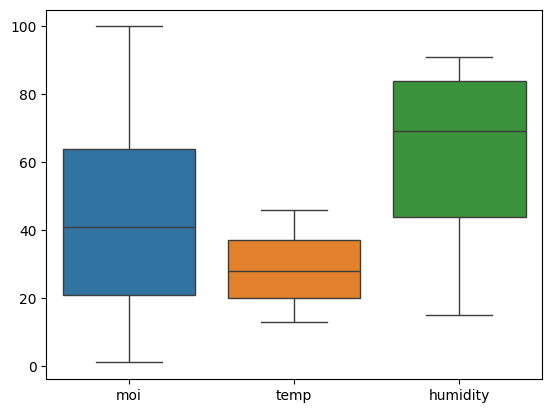

In [ ]:
sns.boxplot(data=df[["moi","temp","humidity"]]) #membuat grafik bloxpot
plt.show() #menampilkan grafik

**Format Datetime**
digunakan untuk mengubah kolom tanggal dari string menjadi tipe data datetime.
dataset yang digunakan tidak memiliki kolom waktu atau timestamp, sehingga tidak perlu proses konversi tipe data ke format datetime

In [ ]:
# df["date"] = pd.to_datetime(df["date"])
#digunakan untuk mengubah kolom tanggal dari string menjadi tipe data datetime

# Data Analysis

bertujuan untuk mengidentifikasi pola dan hubungan antar variabel sensor pertanian

sebelum melakukan analisis korelasi, hanya kolom bertipe numerik yang digunakan karena perhitungan korelasi tidak dapat diterapkan pada data  kategorikal

In [ ]:
numeric_df = df.select_dtypes(include=['number']) #memilih hanya kolom yang bertipe numerik

**Correlation Heatmap**

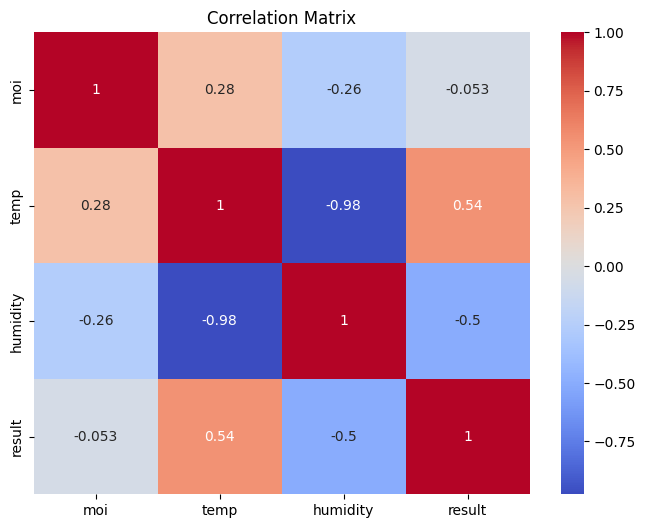

In [ ]:
plt.figure(figsize=(8,6)) #mengatur ukuran grafik agar besar
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm') #membuat visualisasi matriks korelasi dalam bentuk warna
plt.title('Correlation Matrix') #memberi judul grafik
plt.show() #menampilkan grafik

**Time Series Trend**

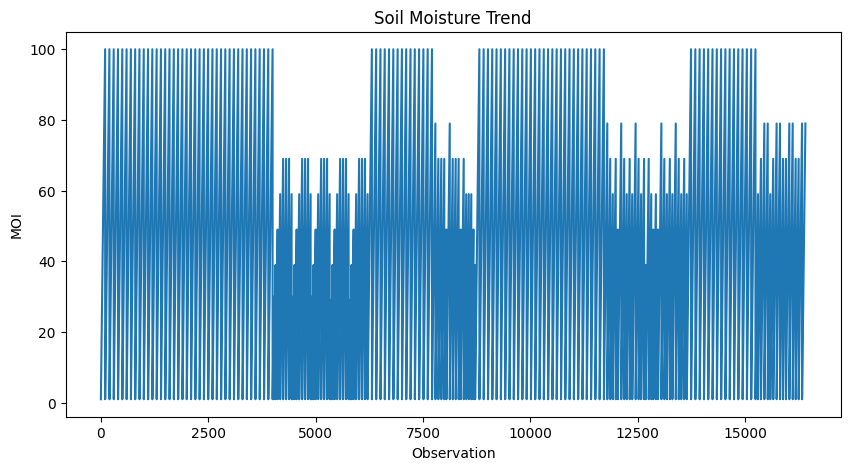

In [ ]:
plt.figure(figsize=(10,5)) #mengatur ukuran grafik
plt.plot(df['moi']) #membuat grafik garis
plt.title("Soil Moisture Trend") #membuat judl grafik
plt.xlabel("Observation") #memberi label pada sumbu x
plt.ylabel("MOI") #memeberi label sumbu y
plt.show() # menampilkan ggrafik

In [ ]:
df.to_csv("cleaned_data.csv", index=False)

# Data Quality Score
 untuk mengukur seberapa bagus kualitas dataset yang kita gunakan sbelum analisis



In [25]:
import pandas as pd #untuk mengolah dataset
import numpy as np #membantu perhitungan numerik

In [27]:
df = pd.read_csv("cleaned_data.csv") #membaca dataset
df.head() #menampilkan 5 baris pertama

,crop_id,soil_type,seedling_stage,moi,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [28]:
df.info() #menampilkan kolom, tipe data, jumlah data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop_id         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   seedling_stage  16411 non-null  object 
 3   moi             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


menghitung missing value

In [31]:
missing_values = df.isnull().sum() #mengecek data kosong
missing_values #menampilkan

,0
crop_id,0
soil_type,0
seedling_stage,0
moi,0
temp,0
humidity,0
result,0


menghiting total missing value

In [32]:
total_missing = df.isnull().sum().sum() #menjumlahkan semua missing value
total_missing

np.int64(0)

menghitung total data

In [33]:
total_values = df.size #menghitung jumlah seluruh sel data
total_values

114877

**Accuracy** berapa banyak data yang tidak bermasalah

In [34]:
accuracy = 1 - (total_missing / total_values)

**Completeness** berapa banyak data ynag tersedia/tidak kosong

In [35]:
completeness = (total_values - total_missing) / total_values

print("Total Data:", total_values)
print("Missing Values:", total_missing)
print("Accuracy Score:", accuracy)
print("Completeness Score:", completeness)

Total Data: 114877
Missing Values: 0
Accuracy Score: 1.0
Completeness Score: 1.0


**Timeliness** apakah data masih relevan atau terbaru. biasanya dihitung dari tanggal data.

di dataset ini tidak mempunyai data tanggal

# **Hasil**

In [36]:
data_quality = pd.DataFrame({
    "Metric": ["Accuracy", "Completeness"],
    "Score": [accuracy, completeness]
})

data_quality

,Metric,Score
0,Accuracy,1.0
1,Completeness,1.0
